# Bonus: Why the Final Answer Is Not Enough for Agents

**O'Reilly Live Course**: *Statistical Testing for LLM Evaluations*  
**Subtitle**: *Design experiments that catch the improvements worth shipping*  
**Instructor**: Rudrendu Paul  
**Bonus notebook (not covered in the 60-minute session)**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RudrenduPaul/statistical-testing-for-llm-evaluations/blob/main/notebooks/04-agent-evaluation-mini-case.ipynb)

---

## What this notebook covers

Same idea as the RAG case, applied to agents: one headline number can pick the wrong winner.

- Two simulated agents, 200 tasks each. Agent A leads on final answer quality. Agent B takes fewer, better steps.
- Scored on four levels (task success, tool selection, trajectory efficiency, final answer quality), Agent B wins two of the four.
- Under simulated production constraints, Agent A falls behind.

All data is synthetic. The production penalties (latency, timeouts, context overflow) are coded-in assumptions that build Agent A's drop, so the result illustrates a mechanism and is not field data.

## How this notebook works

If you skim the code, this picture is the whole story. Each section answers one question, and the outputs below come from these steps.

<img src="https://raw.githubusercontent.com/RudrenduPaul/statistical-testing-for-llm-evaluations/6f5497f/assets/notebook-04-workflow.png" alt="Notebook 04 workflow in twelve steps across three sections: two agents, four levels, production" width="1040">

**Figure 1.** The twelve steps of notebook 04, read left to right and top to bottom. The first four steps set up two agents and score four levels, the next four compare the agents on those levels, and the last four add production limits and show which agent holds up.

## Setup

Standard scientific Python only. Colab-safe: the install step runs only if a package fails to import.

In [1]:
import importlib.util, subprocess, sys
_pkgs = {'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib', 'statsmodels': 'statsmodels'}
_missing = [pip_name for mod, pip_name in _pkgs.items() if importlib.util.find_spec(mod) is None]
if _missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + _missing)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.contingency_tables import mcnemar

np.random.seed(42)   # same numbers on every run

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11,
                     'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3})
AGENT_A_COLOR = '#E07B54'
AGENT_B_COLOR = '#4A90D9'
print('All imports successful.')

All imports successful.


---

## Section 1: Two agents, four metrics

- **Agent A** brute-forces its way to good answers: many steps, many retries, sloppy tool choices.
- **Agent B** plans first and acts precisely: fewer steps, better tool choices, slightly weaker final answers.

| Metric | What it captures |
|---|---|
| `task_success` | Did the agent complete the goal? (0 or 1) |
| `tool_selection_accuracy` | Fraction of steps where the agent picked the right tool |
| `trajectory_efficiency` | Optimal steps divided by steps taken (1.0 is a perfect path) |
| `final_answer_quality` | Quality score for the final output |

In [3]:
N = 200   # tasks per agent

agent_a = pd.DataFrame({
    'agent': 'Agent A', 'task_id': np.arange(N),
    'task_success': np.random.binomial(1, 0.84, N),
    'num_steps': np.random.randint(4, 9, N),
    'tool_selection_accuracy': np.clip(np.random.normal(0.63, 0.12, N), 0.2, 0.95),
    'trajectory_efficiency': np.clip(np.random.normal(0.52, 0.11, N), 0.2, 0.85),
    'final_answer_quality': np.clip(np.random.normal(0.81, 0.09, N), 0.4, 0.99),
})
agent_b = pd.DataFrame({
    'agent': 'Agent B', 'task_id': np.arange(N),
    'task_success': np.random.binomial(1, 0.81, N),
    'num_steps': np.random.randint(2, 6, N),
    'tool_selection_accuracy': np.clip(np.random.normal(0.84, 0.08, N), 0.55, 0.99),
    'trajectory_efficiency': np.clip(np.random.normal(0.79, 0.09, N), 0.5, 0.99),
    'final_answer_quality': np.clip(np.random.normal(0.75, 0.10, N), 0.4, 0.99),
})

df = pd.concat([agent_a, agent_b], ignore_index=True)
summary = df.groupby('agent').agg(
    task_success_rate=('task_success', 'mean'),
    avg_steps=('num_steps', 'mean'),
    tool_selection_accuracy=('tool_selection_accuracy', 'mean'),
    trajectory_efficiency=('trajectory_efficiency', 'mean'),
    final_answer_quality=('final_answer_quality', 'mean'),
).round(3)
print('Simulated data summary:')
print(summary.to_string())

Simulated data summary:
         task_success_rate  avg_steps  tool_selection_accuracy  trajectory_efficiency  final_answer_quality
agent                                                                                                      
Agent A              0.845      6.035                    0.633                  0.515                 0.816
Agent B              0.815      3.505                    0.845                  0.800                 0.755


---

## Section 2: Score all four levels

Looking only at final answer quality, Agent A wins. Looking at all four levels, the picture splits.

Metric                         Agent A   Agent B   Higher
task_success_rate                0.845     0.815   Agent A
tool_selection_accuracy          0.633     0.845   Agent B
trajectory_efficiency            0.515     0.800   Agent B
final_answer_quality             0.816     0.755   Agent A


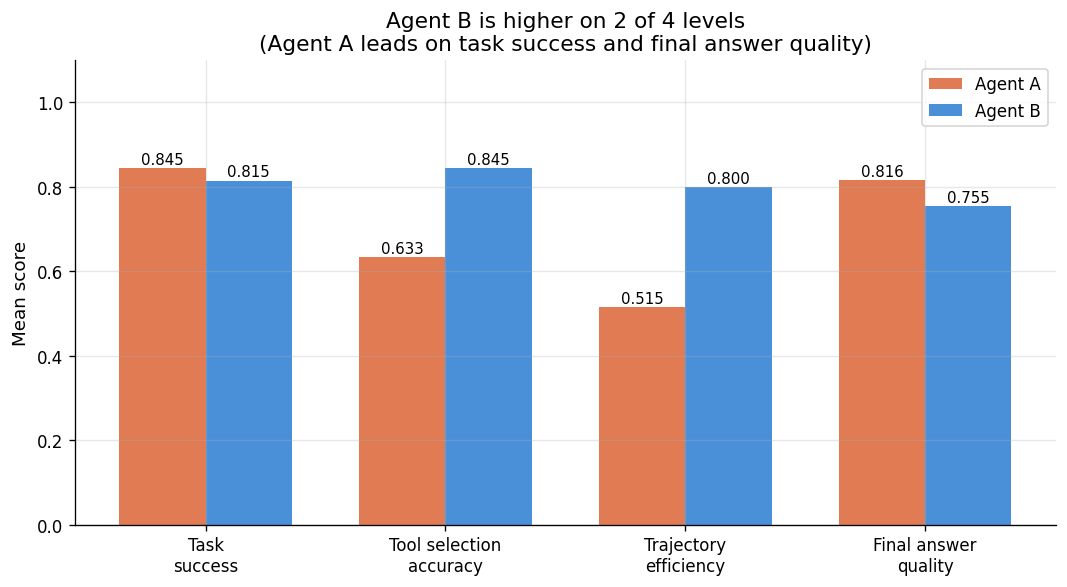

In [4]:
levels = [('task_success_rate', 'Task\nsuccess'), ('tool_selection_accuracy', 'Tool selection\naccuracy'),
          ('trajectory_efficiency', 'Trajectory\nefficiency'), ('final_answer_quality', 'Final answer\nquality')]
a_vals = [summary.loc['Agent A', k] for k, _ in levels]
b_vals = [summary.loc['Agent B', k] for k, _ in levels]

print(f'{"Metric":<28} {"Agent A":>9} {"Agent B":>9}   Higher')
for (k, _), a, b in zip(levels, a_vals, b_vals):
    print(f'{k:<28} {a:>9.3f} {b:>9.3f}   {"Agent A" if a > b else "Agent B"}')

x = np.arange(len(levels)); w = 0.36
fig, ax = plt.subplots(figsize=(9, 5))
bars_a = ax.bar(x - w/2, a_vals, w, color=AGENT_A_COLOR, label='Agent A')
bars_b = ax.bar(x + w/2, b_vals, w, color=AGENT_B_COLOR, label='Agent B')
for bars in (bars_a, bars_b):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.3f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([lab for _, lab in levels])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Mean score')
ax.set_title('Agent B is higher on 2 of 4 levels\n(Agent A leads on task success and final answer quality)')
ax.legend()
plt.tight_layout()
plt.show()

**What this shows**: Agent A's lead is on final answer quality (and a small 3-point lead on task success). Agent B is ahead on the two process metrics, tool selection and trajectory efficiency, which are the ones that drive cost and fragility.

---

## Section 3: Add production constraints

Production adds limits a benchmark does not have. Each penalty below depends on how the agent behaves, so the agent that wanders takes the hits:

- **Latency**: inefficient trajectories make more wasted tool calls, so they risk breaching a latency budget.
- **Timeouts**: tasks with 6 or more steps often run past the time limit.
- **Context overflow**: tasks with 7 or more steps overflow the context window and lose 35% of answer quality.

These rules are assumptions written into the simulation. They build Agent A's drop in.

In [5]:
def apply_production_constraints(agent_df):
    df_prod = agent_df.copy()   # leave the benchmark records untouched

    # Latency: risk grows as trajectory efficiency falls below 0.70 (capped at 25%)
    inefficiency = np.clip(0.70 - df_prod['trajectory_efficiency'], 0, None)
    latency_failures = np.random.binomial(1, np.clip(inefficiency * 0.42, 0, 0.25))

    # Timeout: 22% failure risk at 6+ steps, 2% below
    timeout_failures = np.random.binomial(1, np.where(df_prod['num_steps'] >= 6, 0.22, 0.02))

    # Context overflow at 7+ steps: 35% answer quality penalty
    df_prod.loc[df_prod['num_steps'] >= 7, 'final_answer_quality'] *= 0.65

    # A task fails if either the latency or the timeout penalty triggers
    df_prod.loc[(latency_failures == 1) | (timeout_failures == 1), 'task_success'] = 0
    return df_prod

np.random.seed(42)
agent_a_prod = apply_production_constraints(agent_a)
agent_b_prod = apply_production_constraints(agent_b)

results = pd.DataFrame({
    'Agent': ['Agent A', 'Agent B'],
    'Benchmark success rate': [agent_a['task_success'].mean(), agent_b['task_success'].mean()],
    'Production success rate': [agent_a_prod['task_success'].mean(), agent_b_prod['task_success'].mean()],
})
results['Drop (pp)'] = ((results['Benchmark success rate'] - results['Production success rate']) * 100).round(1)
print('=== Benchmark vs production success rates ===')
print(results.to_string(index=False))

# Paired test: the same 200 tasks appear in both conditions, so use McNemar
def drop_test(bench, prod):
    b_ = int(((bench == 1) & (prod == 0)).sum())   # succeeded on the benchmark, failed in production
    c_ = int(((bench == 0) & (prod == 1)).sum())   # failed on the benchmark, succeeded in production
    return b_, c_, mcnemar([[0, b_], [c_, 0]], exact=True).pvalue

print()
print('=== Is the drop significant? (paired McNemar test) ===')
for name, bench, prod in [('Agent A', agent_a, agent_a_prod), ('Agent B', agent_b, agent_b_prod)]:
    b_, c_, p_ = drop_test(bench['task_success'].values, prod['task_success'].values)
    print(f'{name}: {b_} tasks went from success to failure, {c_} the other way, p = {p_:.4g}')

=== Benchmark vs production success rates ===
  Agent  Benchmark success rate  Production success rate  Drop (pp)
Agent A                   0.845                    0.705       14.0
Agent B                   0.815                    0.795        2.0

=== Is the drop significant? (paired McNemar test) ===
Agent A: 28 tasks went from success to failure, 0 the other way, p = 7.451e-09
Agent B: 4 tasks went from success to failure, 0 the other way, p = 0.125


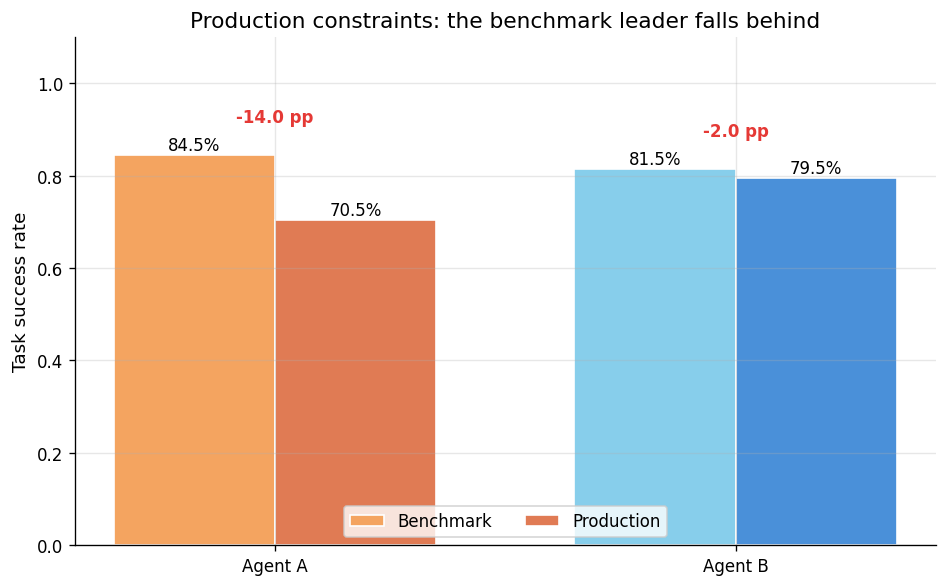

In [6]:
x = np.arange(2); w = 0.35
bench = results['Benchmark success rate'].values
prod = results['Production success rate'].values

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, bench, w, color=['#F4A460', '#87CEEB'], label='Benchmark', edgecolor='white')
b2 = ax.bar(x + w/2, prod, w, color=[AGENT_A_COLOR, AGENT_B_COLOR], label='Production', edgecolor='white')
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.1%}', ha='center', fontsize=10)
for i in range(2):
    ax.text(x[i], max(bench[i], prod[i]) + 0.07, f'-{(bench[i] - prod[i]) * 100:.1f} pp', ha='center', color='#E53935', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Agent A', 'Agent B'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Task success rate')
ax.set_title('Production constraints: the benchmark leader falls behind')
ax.legend(loc='lower center', ncol=2)
plt.tight_layout()
plt.show()

---

## Takeaway

- A final-answer score picks Agent A. Process metrics (tool selection, trajectory efficiency) favor Agent B.
- Under the simulated production constraints, Agent A's task success falls from 84.5% to 70.5% (a significant drop). Agent B's falls from 81.5% to 79.5%, a small drop that is not significant at 200 tasks.
- Score the process, then stress it, before trusting the final answer.

*This notebook accompanies the O'Reilly Live Course: **Statistical Testing for LLM Evaluations**, by Rudrendu Paul. All data is simulated.*